In [9]:
import pandas as pd

# Reload only what we need for the patient-gene pivot
md_raw = pd.read_csv('../../luad_tcga_pan_can_atlas_2018/data_mutations.txt',
                     sep='\t',
                     usecols=['Tumor_Sample_Barcode', 'Hugo_Symbol', 'FILTER', 'NCALLERS'],
                     low_memory=False)

# Apply the same quality row filters we applied before
md_pivot = md_raw[(md_raw['FILTER'] == 'PASS') & (md_raw['NCALLERS'] >= 2)]

print(md_pivot.shape)
print(md_pivot.head(3))


(196070, 4)
  Hugo_Symbol Tumor_Sample_Barcode FILTER  NCALLERS
0        CPN1      TCGA-05-4244-01   PASS         5
1       MKI67      TCGA-05-4244-01   PASS         2
2        NEBL      TCGA-05-4244-01   PASS         3


In [10]:
mutation_matrix = (
    md_pivot.groupby(['Tumor_Sample_Barcode', 'Hugo_Symbol'])
    .size()
    .unstack(fill_value=0)
    .gt(0)
    .astype(int)
)

print(mutation_matrix.shape)

(508, 18778)


In [11]:
mutation_matrix.head()

Hugo_Symbol,A1BG,A1BG-AS1,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3,hsa-mir-6080,hsa-mir-7162
Tumor_Sample_Barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-05-4244-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4249-01,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4250-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
TCGA-05-4382-01,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
TCGA-05-4384-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
mutation_matrix.index

Index(['TCGA-05-4244-01', 'TCGA-05-4249-01', 'TCGA-05-4250-01',
       'TCGA-05-4382-01', 'TCGA-05-4384-01', 'TCGA-05-4389-01',
       'TCGA-05-4390-01', 'TCGA-05-4395-01', 'TCGA-05-4396-01',
       'TCGA-05-4397-01',
       ...
       'TCGA-NJ-A4YG-01', 'TCGA-NJ-A4YI-01', 'TCGA-NJ-A4YP-01',
       'TCGA-NJ-A4YQ-01', 'TCGA-NJ-A55A-01', 'TCGA-NJ-A55O-01',
       'TCGA-NJ-A55R-01', 'TCGA-NJ-A7XG-01', 'TCGA-O1-A52J-01',
       'TCGA-S2-AA1A-01'],
      dtype='object', name='Tumor_Sample_Barcode', length=508)

In [13]:
mutation_matrix.index = mutation_matrix.index.str[:12]

## Merge the data with the Clinical data

STEP A — Merge & finalise the ML dataset
  1. Merge mutation_matrix + clinical on PATIENT_ID (inner join)
  2. Separate X (gene features) and y (OS_STATUS)
  3. Expected result: ~440 patients × 18,779 features

In [14]:
# Read the selected clinical data.

cd = pd.read_csv('../Data/processed_data/selected_clinical.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../Data/processed_data/mutation_data_processed/selected_clinical.csv'

In [ ]:
cd.shape

(463, 11)

### For predicting the OS_status (target : y)
### X : columns selcted from the mutation data.

In [ ]:
required_os_data = cd[['PATIENT_ID', 'OS_STATUS']]

In [ ]:

mm = mutation_matrix.reset_index()

mm = mm.rename(columns={'Tumor_Sample_Barcode':'PATIENT_ID'})
mm.shape

mc = pd.merge(mm,  required_os_data, on='PATIENT_ID', how='inner')

In [ ]:
df = mc
mc.shape

(458, 18780)

In [ ]:
mc.head()

,PATIENT_ID,A1BG,A1BG-AS1,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,...,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3,hsa-mir-6080,hsa-mir-7162,OS_STATUS
0,TCGA-05-4249,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,TCGA-05-4382,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,TCGA-05-4384,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,TCGA-05-4389,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,TCGA-05-4390,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
for col in mc.columns.tolist()[1:-2]:
    if mc[col].nunique() == 1:
        print(col)

A3GALT2
A4GALT
ABHD17A
ADRM1
AES
AGPAT5
AMY1B
ANGPTL6
AP000266.7
AP1S3
APEH
ASCL1
ATG14
ATP5L2
ATP8B5P
BCCIP
BCS1L
BIN3
C10orf111
C11orf31
C11orf80
C12orf43
C15orf54
C1orf86
C3orf55
C4orf27
C4orf29
C4orf45
C9orf47
CACNA1C-AS1
CBFB
CCDC58
CCR9
CD68
CDPF1
CEBPB
CEP19
CES4A
CGB8
CHP1
CIRBP-AS1
CLCF1
CLDN1
CLIC4
COX5A
CRCT1
CSNK2B
CT47A6
CTD-2587H24.5
CXorf58
CYB561
CYB5B
CYS1
DEGS1
DHODH
DOK4
DUSP28
DYNLT1
EFNA4
EGFL7
ELOVL1
ENHO
ETV4
EXOSC6
FAM131C
FAM133B
FAM187A
FAM200A
FAM219A
FAM53A
FAR2P1
FBXO36
FCF1
FITM1
FKBP11
FKBP7
FOXD2
FOXE3
GAL
GAS2L1
GFER
GLO1
GOLGA8B
GPX4
GSC
GSTK1
GSTT2
GTPBP6
H1FX
H2AFV
HABP4
HEXB
HLA-DPB1
HNRNPDL
HPCAL1
HSDL2
ID4
IDH2
IFITM5
IGFBP6
IGLJ2
IGLV4-69
IKZF5
IL10
IL11
IL6ST
ING5
INO80B
KHDC1L
KLF13
KLHDC9
KLRC4-KLRK1
KNCN
KRT42P
KXD1
LINC00475
LSMD1
LTBR
MANF
MAPK8IP2
MED29
MED4
METRNL
MIR1200
MIR30E
MIR450A2
MIR488
MIR520F
MIR542
MIR575
MIR587
MIR592
MIR640
MIR665
MIR9-3
MIR934
MPP5
MSL1
MUCL1
NAA38
NDUFAF7
NDUFB3
NDUFB6
NDUFV1
NDUFV2
NEURL2
NKIRAS1
NMNAT3
NU

STEP B — Step 4: ANOVA (statistical filter)
  1. Run f_classif(X, y) → F-score + p-value for every gene
  2. Apply FDR correction → adjusted p-values
  3. Keep genes with p_adjusted < 0.05
  4. Expected result: shortlist of ~50-200 significant genes

In [ ]:
X = df.drop(columns=['PATIENT_ID', 'OS_STATUS'])
y = df['OS_STATUS']

print("Features (patients × genes):", X.shape)
print("Target distribution:\n", y.value_counts())

Features (patients × genes): (458, 18778)
Target distribution:
 OS_STATUS
0    291
1    167
Name: count, dtype: int64


In [ ]:
from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(X, y)

anova_results = pd.DataFrame({
    'gene':    X.columns,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('p_value').reset_index(drop=True)

print(anova_results.head(15))

       gene    f_score   p_value
0     MROH9  14.631200  0.000149
1     XIRP1  10.992263  0.000988
2      DVL3  10.832757  0.001075
3     NBPF1  10.316068  0.001412
4     CHDC2   9.396243  0.002303
5      XCL1   9.300467  0.002424
6     GMEB2   9.300467  0.002424
7   C3orf30   9.036453  0.002793
8      PFKP   8.942261  0.002937
9   FAM166A   8.942261  0.002937
10   FAM83A   8.942261  0.002937
11      GML   8.942261  0.002937
12   PRKAG2   8.942261  0.002937
13     KAT7   8.942261  0.002937
14    ATG2B   8.869631  0.003054


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [    5     6    90   394   402   447   652   679   799   808   840  1110
  1176  1244  1282  1428  1461  1505  1673  1701  1720  1734  1784  1928
  2002  2019  2020  2026  2130  2175  2340  2465  2584  2669  2808  2835
  2890  2925  2950  3019  3088  3117  3127  3181  3437  3515  3622  3650
  3683  3794  3798  3801  3882  4094  4156  4372  4503  4532  4635  4646
  4750  4807  4979  5021  5126  5129  5190  5209  5234  5275  5360  5433
  5462  5586  5591  5600  5680  5688  5878  5928  6025  6137  6252  6432
  6504  6527  6536  6570  6612  6614  6626  6763  6878  6938  7006  7068
  7166  7169  7204  7263  7383  7416  7447  7448  7451  7526  7559  7568
  7972  8129  8149  8207  8217  8280  8388  8620  8857  8872  9020  9082
  9247  9250  9291  9413  9470  9494  9501  9539  9551  9565  9569  9570
  9582  9593  9609  9613  9758  9907 10018 10156 10324 10329 10

In [ ]:
anova_results.head()

,gene,f_score,p_value
0,MROH9,14.631200,0.000149
1,XIRP1,10.992263,0.000988
2,DVL3,10.832757,0.001075
3,NBPF1,10.316068,0.001412
4,CHDC2,9.396243,0.002303


In [ ]:
# Drop genes where f_classif returned NaN (constant columns)
anova_clean = anova_results.dropna(subset=['f_score', 'p_value'])
print(f"Genes with valid F-scores: {len(anova_clean)} / {len(anova_results)}")
print(anova_clean.head(15))


Genes with valid F-scores: 18529 / 18778
       gene    f_score   p_value
0     MROH9  14.631200  0.000149
1     XIRP1  10.992263  0.000988
2      DVL3  10.832757  0.001075
3     NBPF1  10.316068  0.001412
4     CHDC2   9.396243  0.002303
5      XCL1   9.300467  0.002424
6     GMEB2   9.300467  0.002424
7   C3orf30   9.036453  0.002793
8      PFKP   8.942261  0.002937
9   FAM166A   8.942261  0.002937
10   FAM83A   8.942261  0.002937
11      GML   8.942261  0.002937
12   PRKAG2   8.942261  0.002937
13     KAT7   8.942261  0.002937
14    ATG2B   8.869631  0.003054


In [ ]:
X.shape

(458, 18778)

In [ ]:
# Remove constant gene columns from the feature matrix itself
X = X.loc[:, X.nunique() > 1]
print("X shape after removing constant columns:", X.shape)


X shape after removing constant columns: (458, 18529)


In [ ]:
# install statsmodels
# !pip install statsmodels

In [ ]:
from statsmodels.stats.multitest import fdrcorrection

rejected, p_adjusted = fdrcorrection(anova_results['p_value'], alpha=0.05)

anova_results['p_adjusted'] = p_adjusted
anova_results['significant'] = rejected

significant = anova_results[anova_results['significant'] == True]
print(f"Total genes tested:        {len(anova_results)}")
print(f"Significant after FDR:     {len(significant)}")
print(f"\nTop significant genes:\n{significant.head(20)}")

Total genes tested:        18778
Significant after FDR:     0

Top significant genes:
Empty DataFrame
Columns: [gene, f_score, p_value, p_adjusted, significant]
Index: []


In [ ]:
# Keep genes mutated in at least 5% of patients
min_patients = int(0.05 * X.shape[0])
print(f"Minimum mutation count threshold: {min_patients} patients")

gene_freq = X.sum(axis=0)                        # how many patients have each gene mutated
frequent_genes = gene_freq[gene_freq >= min_patients].index

X_filtered = X[frequent_genes]
print(f"Genes before frequency filter: {X.shape[1]}")
print(f"Genes after  frequency filter: {X_filtered.shape[1]}")


Minimum mutation count threshold: 22 patients
Genes before frequency filter: 18529
Genes after  frequency filter: 1406


In [ ]:
from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(X_filtered, y)

anova_results = pd.DataFrame({
    'gene':    X_filtered.columns,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('p_value').reset_index(drop=True)

print(anova_results.head(15))


       gene    f_score   p_value
0     MROH9  14.631200  0.000149
1     XIRP1  10.992263  0.000988
2     CHDC2   9.396243  0.002303
3      SETX   8.167706  0.004459
4     MYT1L   8.116063  0.004586
5    ZNF257   8.064982  0.004715
6    MPPED2   8.064982  0.004715
7    PLXNA4   7.696473  0.005760
8    PCNXL2   7.664587  0.005861
9    BCLAF1   7.612551  0.006030
10   SLC4A1   7.564497  0.006190
11     MYH4   7.541123  0.006269
12    DMXL1   7.502138  0.006404
13  NAALAD2   7.479836  0.006483
14    LAMB3   7.453398  0.006577


In [ ]:
anova_results['p_value'].describe()

count    1406.000000
mean        0.496560
std         0.289728
min         0.000149
25%         0.242986
50%         0.501852
75%         0.744166
max         0.999171
Name: p_value, dtype: float64

In [ ]:
from statsmodels.stats.multitest import fdrcorrection

rejected, p_adjusted = fdrcorrection(anova_results['p_value'], alpha=0.05)


In [ ]:
anova_results['p_adjusted'] = p_adjusted
anova_results['significant'] = rejected

In [ ]:
significant = anova_results[anova_results['significant'] == True]

In [ ]:
print(f"Genes tested after frequency filter: {len(anova_results)}")
print(f"Significant after FDR:               {len(significant)}")
print(significant.head(20))


Genes tested after frequency filter: 1406
Significant after FDR:               0
Empty DataFrame
Columns: [gene, f_score, p_value, p_adjusted, significant]
Index: []


In [ ]:
shortlist = anova_results[anova_results['p_value'] < 0.05].copy()
print(f"Shortlisted genes: {len(shortlist)}")
print(shortlist.head(20))


Shortlisted genes: 72
       gene    f_score   p_value  p_adjusted  significant
0     MROH9  14.631200  0.000149    0.209401        False
1     XIRP1  10.992263  0.000988    0.616468        False
2     CHDC2   9.396243  0.002303    0.616468        False
3      SETX   8.167706  0.004459    0.616468        False
4     MYT1L   8.116063  0.004586    0.616468        False
5    ZNF257   8.064982  0.004715    0.616468        False
6    MPPED2   8.064982  0.004715    0.616468        False
7    PLXNA4   7.696473  0.005760    0.616468        False
8    PCNXL2   7.664587  0.005861    0.616468        False
9    BCLAF1   7.612551  0.006030    0.616468        False
10   SLC4A1   7.564497  0.006190    0.616468        False
11     MYH4   7.541123  0.006269    0.616468        False
12    DMXL1   7.502138  0.006404    0.616468        False
13  NAALAD2   7.479836  0.006483    0.616468        False
14    LAMB3   7.453398  0.006577    0.616468        False
15  SLITRK6   7.048482  0.008211    0.680050      

In [ ]:
shortlist_genes = shortlist['gene'].tolist()
X_short = X_filtered[shortlist_genes]
print(X_short.shape)   # expect (440ish, 72)


(458, 72)


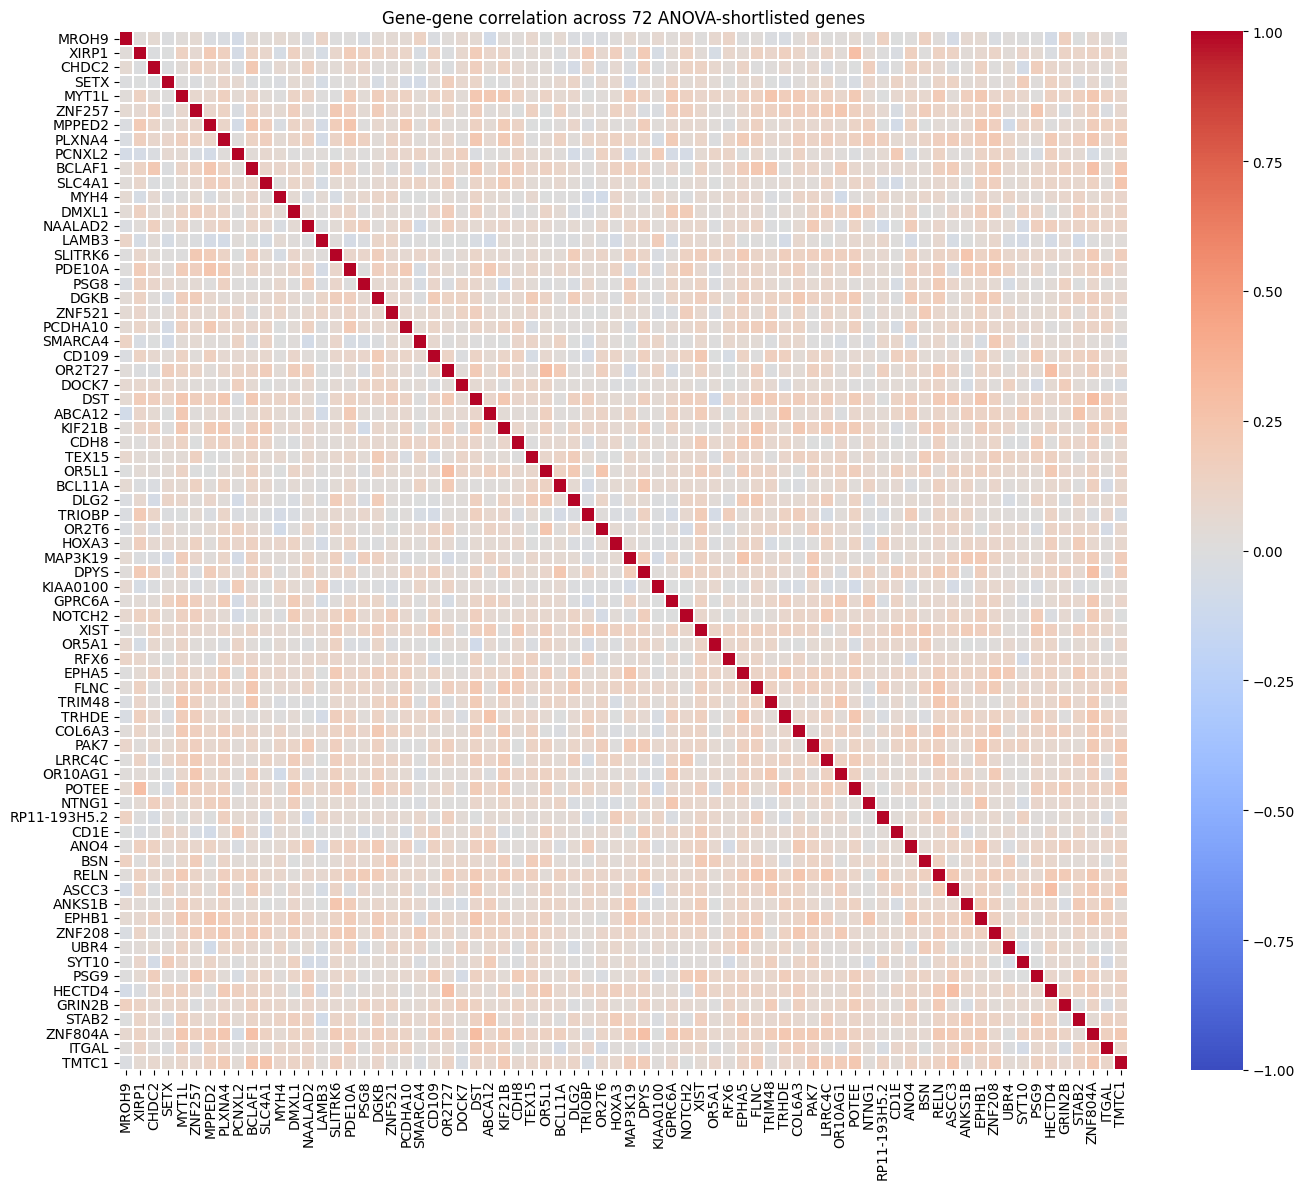

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_short.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            xticklabels=True,
            yticklabels=True,
            ax=ax,
            linewidths=0.3)
ax.set_title('Gene-gene correlation across 72 ANOVA-shortlisted genes')
plt.tight_layout()
plt.show()


In [ ]:
# Find pairs with |correlation| > 0.85
to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            col_j = corr_matrix.columns[j]
            to_drop.add(col_j)
            print(f"Drop {col_j}  ← correlated with {corr_matrix.columns[i]}  (r={corr_matrix.iloc[i,j]:.2f})")

X_clean = X_short.drop(columns=list(to_drop))
print(f"\nGenes before correlation filter: {X_short.shape[1]}")
print(f"Genes after  correlation filter: {X_clean.shape[1]}")



Genes before correlation filter: 72
Genes after  correlation filter: 72


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced')
rf.fit(X_clean, y)

rf_importance = pd.DataFrame({
    'gene':       X_clean.columns,
    'rf_score':   rf.feature_importances_
}).sort_values('rf_score', ascending=False).reset_index(drop=True)

print(rf_importance.head(20))


       gene  rf_score
0    COL6A3  0.029794
1      MYH4  0.026536
2     MROH9  0.023932
3    ZNF521  0.023815
4    GRIN2B  0.021195
5       DST  0.020785
6     LAMB3  0.019718
7      RELN  0.019454
8   ZNF804A  0.019328
9    PCNXL2  0.019085
10     CD1E  0.019000
11    MYT1L  0.018837
12    CHDC2  0.018536
13     XIST  0.018027
14    TEX15  0.017577
15     UBR4  0.017241
16     SETX  0.016965
17  PCDHA10  0.016828
18    DOCK7  0.016400
19    XIRP1  0.016387


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, class_weight='balanced')
lasso.fit(X_scaled, y)

lasso_importance = pd.DataFrame({
    'gene':        X_clean.columns,
    'lasso_coef':  abs(lasso.coef_[0])
}).sort_values('lasso_coef', ascending=False).reset_index(drop=True)

non_zero = lasso_importance[lasso_importance['lasso_coef'] > 0]
print(f"Genes selected by LASSO (non-zero coefficient): {len(non_zero)}")
print(non_zero.head(20))


Genes selected by LASSO (non-zero coefficient): 59
       gene  lasso_coef
0     CHDC2    0.277431
1      SETX    0.277253
2     MROH9    0.236171
3    COL6A3    0.221303
4      DGKB    0.188907
5     XIRP1    0.186774
6     OR5A1    0.182140
7     DOCK7    0.173460
8    ZNF521    0.171811
9     TEX15    0.165853
10    MYT1L    0.163309
11   GRIN2B    0.159786
12   SLC4A1    0.155294
13  PCDHA10    0.136571
14     MYH4    0.129838
15     PSG8    0.124366
16     RFX6    0.122169
17     CD1E    0.114203
18  SLITRK6    0.110504
19   PCNXL2    0.105571


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [ ]:
rf_top = set(rf_importance.head(30)['gene'])
lasso_selected = set(non_zero['gene'])

consensus = rf_top & lasso_selected
print(f"Consensus genes (in RF top 30 AND LASSO non-zero): {len(consensus)}")
print(sorted(consensus))


Consensus genes (in RF top 30 AND LASSO non-zero): 27
['BCLAF1', 'CD1E', 'CDH8', 'CHDC2', 'COL6A3', 'DGKB', 'DOCK7', 'FLNC', 'GRIN2B', 'KIAA0100', 'LAMB3', 'MROH9', 'MYH4', 'MYT1L', 'NAALAD2', 'NTNG1', 'PCDHA10', 'PCNXL2', 'RELN', 'RFX6', 'SETX', 'TEX15', 'UBR4', 'XIRP1', 'XIST', 'ZNF208', 'ZNF521']


In [ ]:
# Merge RF and LASSO scores for the consensus genes
rf_sub    = rf_importance[rf_importance['gene'].isin(consensus)].set_index('gene')
lasso_sub = lasso_importance[lasso_importance['gene'].isin(consensus)].set_index('gene')

In [ ]:
len(rf_sub)

27

In [ ]:
len(lasso_sub)

27

In [ ]:
final = rf_sub.join(lasso_sub).sort_values('rf_score', ascending=True)

In [ ]:
len(final)

27

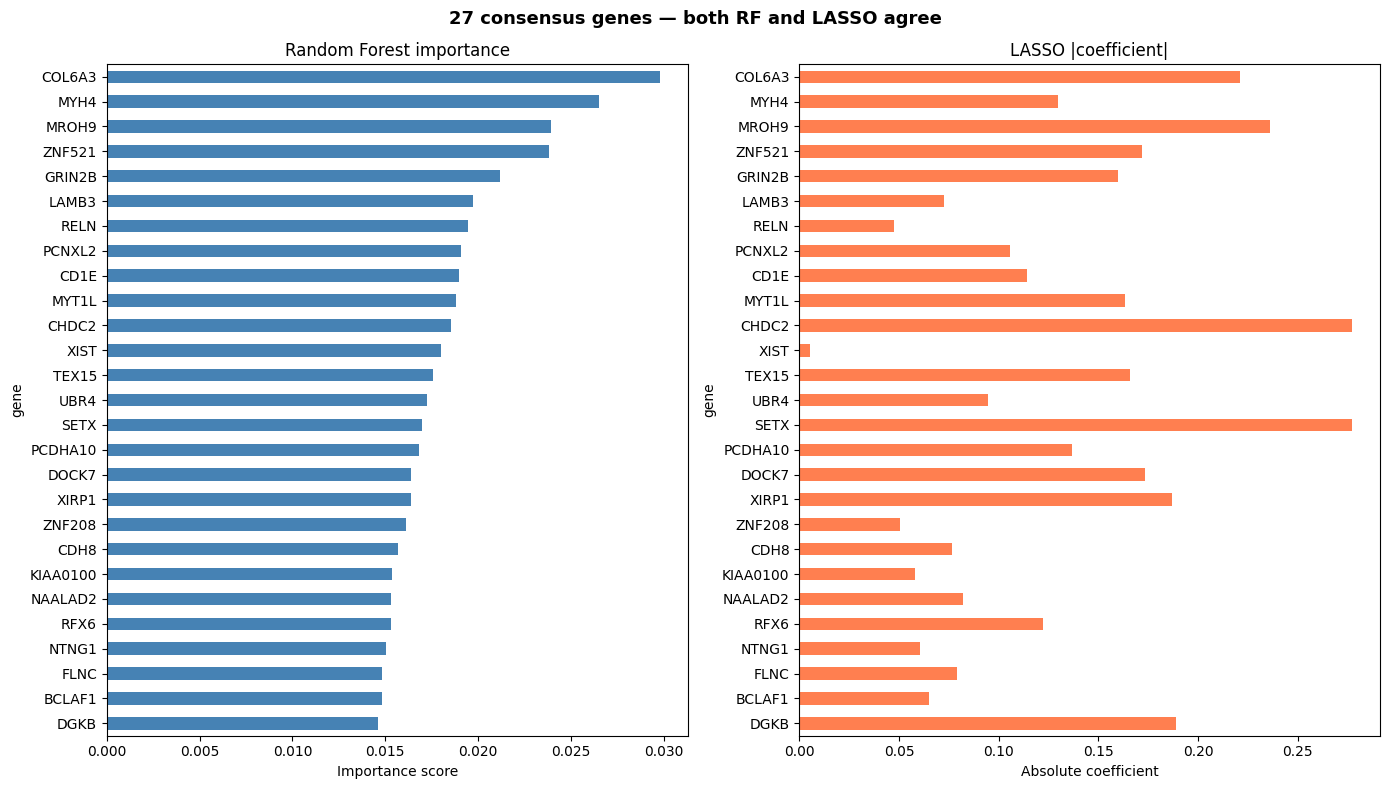

In [ ]:
import matplotlib.pyplot as plt



fig, axes = plt.subplots(1, 2, figsize=(14, 8))

final['rf_score'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest importance')
axes[0].set_xlabel('Importance score')

final['lasso_coef'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('LASSO |coefficient|')
axes[1].set_xlabel('Absolute coefficient')

plt.suptitle('27 consensus genes — both RF and LASSO agree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
final_features = final.reset_index().rename(columns={'index': 'gene'})
final_features['anova_p_value'] = final_features['gene'].map(
    anova_results.set_index('gene')['p_value']
)
final_features = final_features.sort_values('rf_score', ascending=False)

print(final_features)
final_features.to_csv('../Data/processed_data/mutation_matrix_selected_features.csv', index=False)
print("\nSaved to Data/processed_data/mutation_matrix_selected_features.csv")


        gene  rf_score  lasso_coef  anova_p_value
26    COL6A3  0.029794    0.221303       0.028301
25      MYH4  0.026536    0.129838       0.006269
24     MROH9  0.023932    0.236171       0.000149
23    ZNF521  0.023815    0.171811       0.010932
22    GRIN2B  0.021195    0.159786       0.040525
21     LAMB3  0.019718    0.072517       0.006577
20      RELN  0.019454    0.047763       0.038182
19    PCNXL2  0.019085    0.105571       0.005861
18      CD1E  0.019000    0.114203       0.034164
17     MYT1L  0.018837    0.163309       0.004586
16     CHDC2  0.018536    0.277431       0.002303
15      XIST  0.018027    0.005482       0.022993
14     TEX15  0.017577    0.165853       0.019824
13      UBR4  0.017241    0.094486       0.039737
12      SETX  0.016965    0.277253       0.004459
11   PCDHA10  0.016828    0.136571       0.011800
10     DOCK7  0.016400    0.173460       0.012525
9      XIRP1  0.016387    0.186774       0.000988
8     ZNF208  0.016139    0.050342       0.039401





# PCA

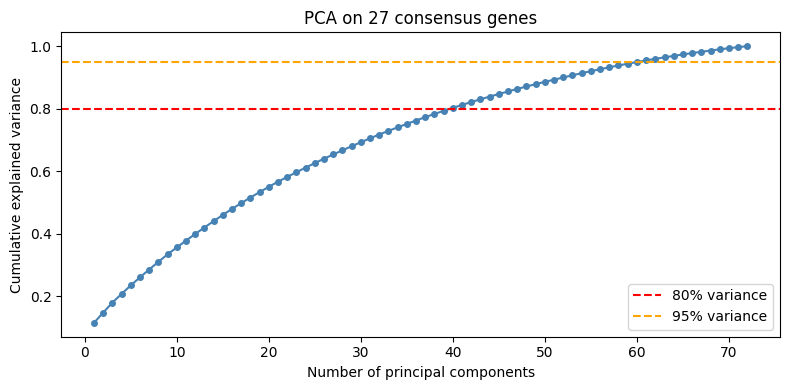

80% variance explained by 40 components
90% variance explained by 53 components
95% variance explained by 61 components


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(final_features)

# Cumulative variance explained
cumvar = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=4, color='steelblue')
plt.axhline(y=0.80, color='red',    linestyle='--', label='80% variance')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA on 27 consensus genes')
plt.legend()
plt.tight_layout()
plt.show()

for threshold in [0.80, 0.90, 0.95]:
    n = (cumvar >= threshold).argmax() + 1
    print(f"{int(threshold*100)}% variance explained by {n} components")


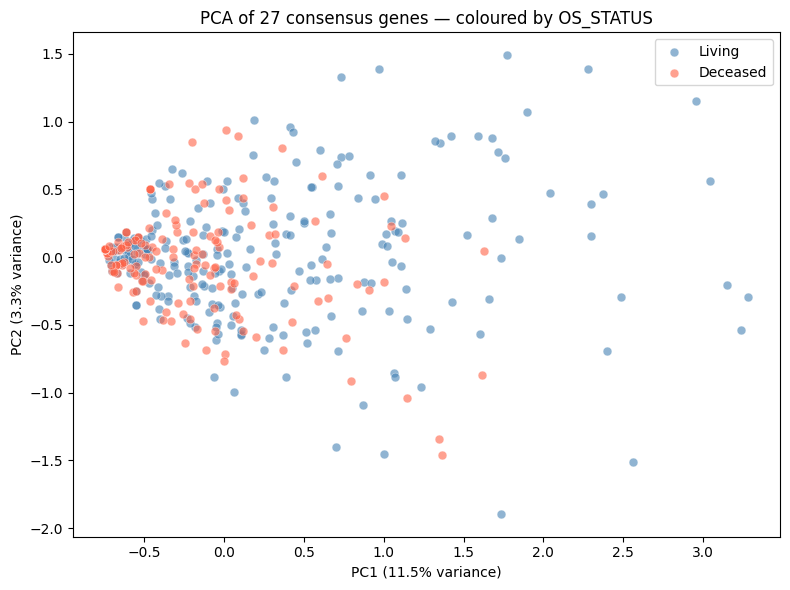

In [175]:
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(X_clean)

plt.figure(figsize=(8, 6))
colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Living', 1: 'Deceased'}

for status in [0, 1]:
    mask = y == status
    plt.scatter(coords[mask, 0], coords[mask, 1],
                c=colors[status], label=labels[status],
                alpha=0.6, edgecolors='white', linewidth=0.4, s=40)

plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA of 27 consensus genes — coloured by OS_STATUS')
plt.legend()
plt.tight_layout()
plt.show()


In [178]:
#install umap
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 18.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 32.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [numba]


/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/mlops/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


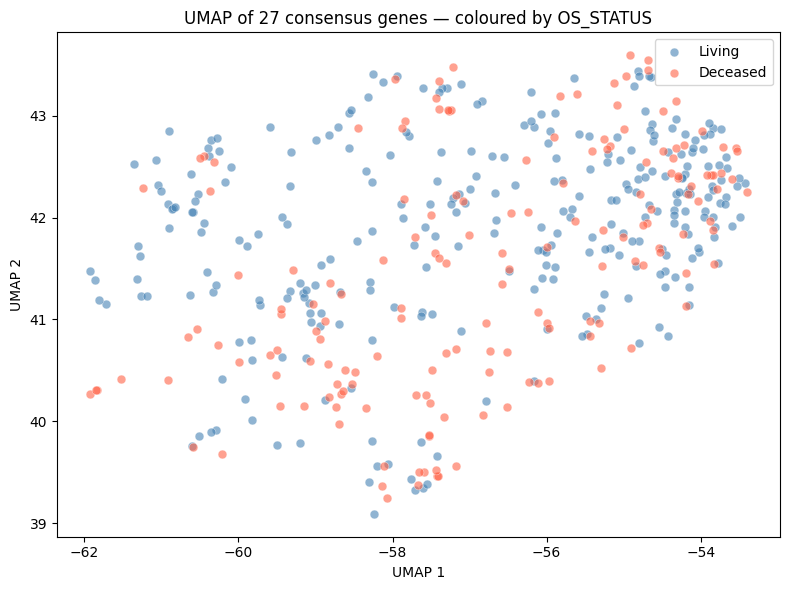

In [179]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_clean)

plt.figure(figsize=(8, 6))
for status in [0, 1]:
    mask = y == status
    plt.scatter(embedding[mask, 0], embedding[mask, 1],
                c=colors[status], label=labels[status],
                alpha=0.6, edgecolors='white', linewidth=0.4, s=40)

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP of 27 consensus genes — coloured by OS_STATUS')
plt.legend()
plt.tight_layout()
plt.show()


In [180]:
X_clean.head()

,MROH9,XIRP1,CHDC2,SETX,MYT1L,ZNF257,MPPED2,PLXNA4,PCNXL2,BCLAF1,...,ZNF208,UBR4,SYT10,PSG9,HECTD4,GRIN2B,STAB2,ZNF804A,ITGAL,TMTC1
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,1,1,0,1,0,1,1,0,0,...,0,0,0,1,0,1,0,1,1,0
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,0,0,1


In [181]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: OS_STATUS, dtype: int64

In [ ]:
# Save X_clean (27 genes) + y (OS_STATUS) together
ml_ready = X_clean.copy()
ml_ready['OS_STATUS'] = y.values
# ml_ready.to_csv('../Data/processed_data/ml_ready_27_genes.csv', index=True)
ml_ready.to_csv('../Data/processed_data/ml_ready_72_genes.csv', index=True)
print("Saved:", ml_ready.shape)   # expect (~440, 28)


Saved: (458, 73)
